# 常用的图像滤波算法——以OpenCV库函数为例

图像滤波是图像处理中的一个重要环节，主要用于去噪、平滑、边缘检测等操作。OpenCV库提供了多种图像滤波算法，下面将介绍几种常用的滤波方法及其在OpenCV中的实现。

## 1. 均值滤波（Mean Filtering）
均值滤波是一种简单的线性滤波方法，通过计算邻域像素的平均值来平滑图像。它可以有效地去除高频噪声，但可能会导致图像边缘模糊。

在均值滤波中，输出像素值等于当前像素邻域内所有像素值的算术平均值。对于灰度图像，设原图像为 $f(x,y)$，滤波后图像为 $g(x,y)$，窗口大小为 $m\times n$，则：

$$g(x,y)=\frac{1}{mn}\sum_{i=-a}^{a}\sum_{j=-b}^{b} f(x+i,\,y+j)$$

其中：

- $a=\frac{m-1}{2}$
- $b=\frac{n-1}{2}$

例如，5×5 窗口时：

$$g(x,y)=\frac{1}{25}\sum_{i=-2}^{2}\sum_{j=-2}^{2} f(x+i,\,y+j)$$

这相当于用一个所有元素都相等的卷积核 $(h)$ 对图像进行卷积：

$$h(u,v)=\frac{1}{mn},\quad u=1,\dots,m,\;v=1,\dots,n$$

因此：

$$g(x,y)=(f*h)(x,y)$$

对于彩色图像，均值滤波通常对每个通道分别计算。

均值滤波的效果是平滑图像、降低噪声，但也会使边缘变得模糊，因为所有邻域像素一视同仁。

在OpenCV中，可以使用`cv2.blur()`函数实现均值滤波。示例代码如下：

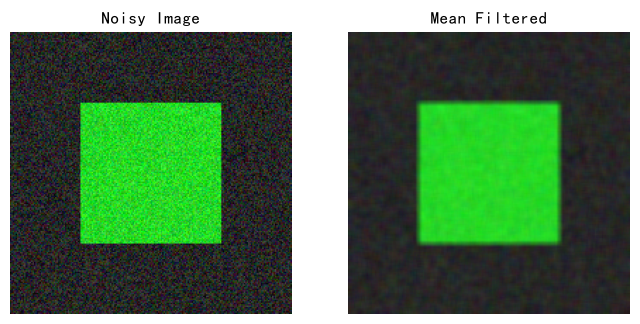

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 设置matplot中文支持
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 创建一个带噪声的彩色图像
img = np.zeros((200, 200, 3), dtype=np.uint8)
img[50:150, 50:150] = (0, 255, 0)
noise = np.random.randint(0, 256, img.shape, dtype=np.uint8)
noisy = cv2.addWeighted(img, 0.7, noise, 0.3, 0)

# 均值滤波
blur = cv2.blur(noisy, (5, 5))

# 显示结果
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Noisy Image")
plt.axis("off")
plt.imshow(cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.title("Mean Filtered")
plt.axis("off")
plt.imshow(cv2.cvtColor(blur, cv2.COLOR_BGR2RGB))
plt.show()

## 2. 高斯滤波（Gaussian Filtering）
高斯滤波是一种常用的线性滤波方法，它使用高斯核来对图像进行平滑处理。与均值滤波不同，高斯滤波能够更好地保留图像的边缘信息，同时有效地去除噪声。

高斯滤波采用一个二维高斯函数作为卷积核，对图像进行加权平均。其核心思想是离中心越近的像素权重越大，离中心越远的像素权重越小，因此在平滑噪声的同时，对边缘的保留更好。

高斯核公式为：

$$h(u,v)=\frac{1}{2\pi\sigma^{2}}\exp\left(-\frac{u^{2}+v^{2}}{2\sigma^{2}}\right)$$

其中 $\sigma$ 控制平滑强度，核大小一般为奇数（如 $5\times5$，$7\times7$）。

对图像的高斯滤波可以表示为卷积：

$$g(x,y)=\sum_{i=-a}^{a}\sum_{j=-b}^{b} f(x+i,y+j)\,h(i,j)$$

其中 $a=\frac{m-1}{2}$，$b=\frac{n-1}{2}$。

在实现上，OpenCV 的 `cv2.GaussianBlur()` 会根据给定的核大小和标准差构造高斯核，然后对图像进行卷积，从而得到平滑后的图像。

示例代码如下：

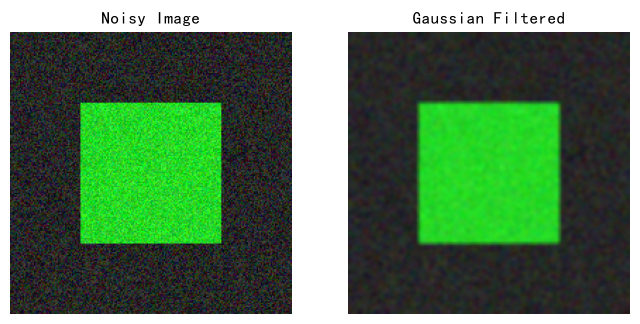

In [2]:
# 高斯滤波处理噪声图像
# 高斯核大小为 5×5，标准差为 1.5
gaussian = cv2.GaussianBlur(noisy, (5, 5), 1.5)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Noisy Image")
plt.axis("off")
plt.imshow(cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.title("Gaussian Filtered")
plt.axis("off")
plt.imshow(cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB))
plt.show()

## 3. 中值滤波（Median Filtering）
中值滤波是一种非线性滤波方法，主要用于去除椒盐噪声。它通过取邻域像素的中值来替代当前像素值，从而有效地去除噪声，同时保留图像的边缘信息。
对于每个像素点，取其邻域内所有像素值并进行排序，然后用排序后的中间值替换当前像素值。对于灰度图像，通常用一个奇数尺寸的窗口（如$3\times3$、$5\times5$）：
$$
g(x,y) = median \{ f(x+i, y+j) | i=-a, \dots, a, j=-b, \dots, b \}
$$
其中 $a=\frac{m-1}{2}$，$b=\frac{n-1}{2}$，$m\times n$ 为窗口大小。对于彩色图像，可对每个通道分别进行中值计算。

这种处理方式能够有效去除椒盐噪声，因为噪声像素值通常是极大值或极小值，排序后不影响中值；同时相比均值滤波，它更能保留图像边缘和细节。

在OpenCV中，可以使用`cv2.medianBlur()`函数实现中值滤波。示例代码如下：


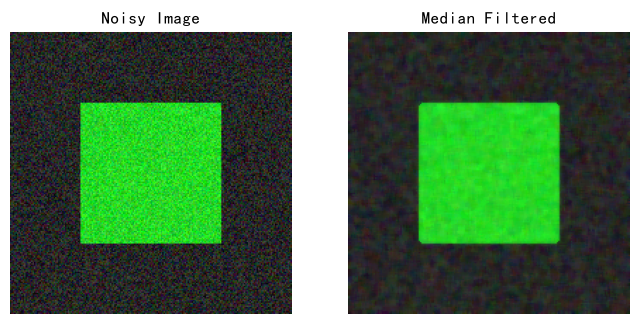

In [3]:
# 中值滤波处理噪声图像
# 使用 5×5 的中值滤波窗口
median = cv2.medianBlur(noisy, 5)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Noisy Image")
plt.axis("off")
plt.imshow(cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.title("Median Filtered")
plt.axis("off")
plt.imshow(cv2.cvtColor(median, cv2.COLOR_BGR2RGB))

plt.show()

## 4. 双边滤波（Bilateral Filtering）
双边滤波是一种非线性滤波方法，它在平滑图像的同时，能够很好地保留边缘信息。与均值滤波和高斯滤波不同，双边滤波不仅考虑像素的空间邻近性，还考虑像素的颜色相似性。

双边滤波在计算时，对每个像素点 $p$ 的输出值 $g(p)$ 由其邻域内像素值的加权平均决定，权重同时依赖空间距离和像素强度差异：

- 空间权重：$G_{\sigma_{d}}=\exp\left(-\frac{\|p-q\|^2}{2\sigma_s^2}\right)$
- 强度权重：$G_{\sigma_{r}}=\exp\left(-\frac{\|I(p)-I(q)\|^2}{2\sigma_r^2}\right)$

注：$\|p - q\|$ 表示像素 $p$ 和 $q$ 的欧氏距离，$\sigma _{d}$ 为空间域标准差；

$\|I(p) - I(q)\|$ 表示像素亮度的差值，$\sigma _{r}$ 为值域标准差。

整体权重为：

$$w(p,q)=\exp\left(-\frac{\|p-q\|^2}{2\sigma_s^2}\right)
          \exp\left(-\frac{\|I(p)-I(q)\|^2}{2\sigma_r^2}\right)$$

归一化后得到滤波结果：

$$g(p)=\frac{1}{W_p}\sum_{q\in N(p)} w(p,q) f(q)$$

其中：

$$W_p=\sum_{q\in N(p)} w(p,q)$$

这里 $N(p)$ 是以 $p$ 为中心的邻域窗口，$\sigma_s$ 控制空间邻近性的影响范围，$\sigma_r$ 控制像素值相似性的影响程度。

因此，双边滤波既考虑像素之间的空间距离，又考虑像素值的相似度，能够在平滑噪声的同时较好地保留边缘。

在OpenCV中，可以使用`cv2.bilateralFilter()`函数实现双边滤波。示例代码如下：

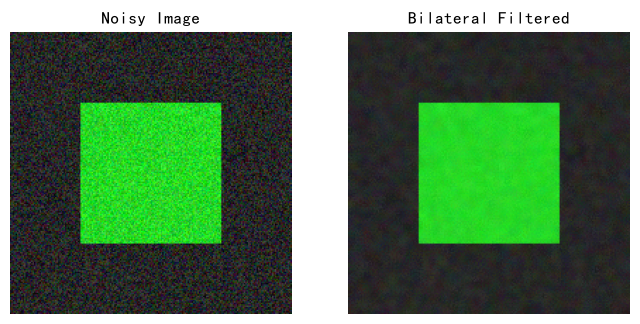

In [4]:
# 双边滤波处理噪声图像
# d=9, sigmaColor=75, sigmaSpace=75
bilateral = cv2.bilateralFilter(noisy, 9, 75, 75)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Noisy Image")
plt.axis("off")
plt.imshow(cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.title("Bilateral Filtered")
plt.axis("off")
plt.imshow(cv2.cvtColor(bilateral, cv2.COLOR_BGR2RGB))
plt.show()

## 5. 总结
本文介绍了几种常用的图像滤波算法，包括均值滤波、高斯滤波、中值滤波和双边滤波，并给出了它们在OpenCV中的实现方法。每种滤波方法都有其适用的场景和特点：
- 均值滤波：简单有效，适用于去除高斯噪声，但会模糊边缘。
- 高斯滤波：能够有效平滑图像，保留更多的边缘信息。
- 中值滤波：对于椒盐噪声有很好的去除效果，能够保持边缘清晰。
- 双边滤波：能够在去除噪声的同时较好地保持图像的边缘信息。

我们以上所述的滤波方法为基础，可以根据具体的图像处理需求选择合适的滤波算法，以达到最佳的图像处理效果。

以`data`目录下的`lena.jpg`图像为例，展示不同滤波方法的效果对比：

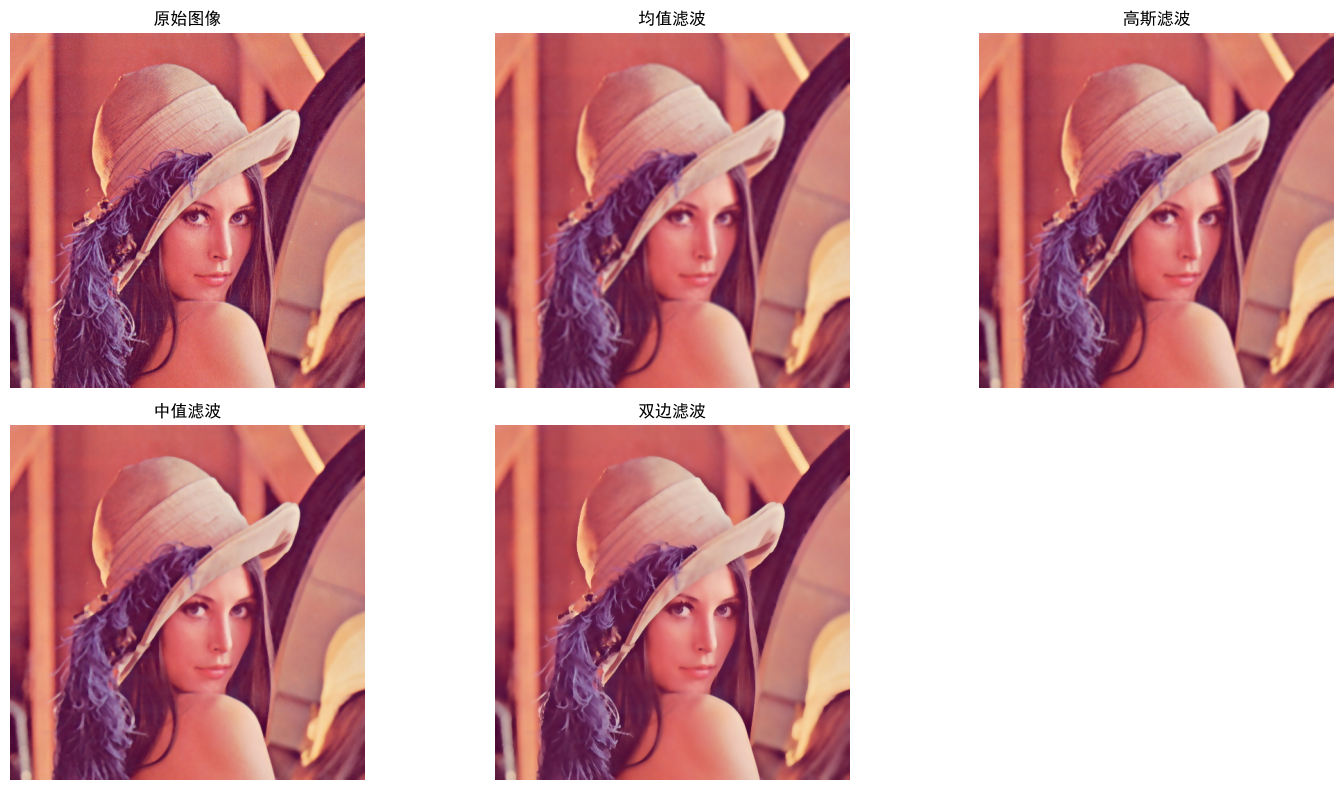

In [5]:
lena = cv2.imread('../data/lena.jpg')
if lena is None:
    raise FileNotFoundError("Cannot find data/lena.jpg")

lena_rgb = cv2.cvtColor(lena, cv2.COLOR_BGR2RGB)

lena_blur = cv2.blur(lena, (5, 5))
lena_gaussian = cv2.GaussianBlur(lena, (5, 5), 1.5)
lena_median = cv2.medianBlur(lena, 5)
lena_bilateral = cv2.bilateralFilter(lena, 9, 75, 75)

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.title("原始图像")
plt.axis("off")
plt.imshow(lena_rgb)

plt.subplot(2, 3, 2)
plt.title("均值滤波")
plt.axis("off")
plt.imshow(cv2.cvtColor(lena_blur, cv2.COLOR_BGR2RGB))

plt.subplot(2, 3, 3)
plt.title("高斯滤波")
plt.axis("off")
plt.imshow(cv2.cvtColor(lena_gaussian, cv2.COLOR_BGR2RGB))

plt.subplot(2, 3, 4)
plt.title("中值滤波")
plt.axis("off")
plt.imshow(cv2.cvtColor(lena_median, cv2.COLOR_BGR2RGB))

plt.subplot(2, 3, 5)
plt.title("双边滤波")
plt.axis("off")
plt.imshow(cv2.cvtColor(lena_bilateral, cv2.COLOR_BGR2RGB))

plt.tight_layout()
plt.show()